In [3]:
from google.colab import files

uploaded = files.upload()

Saving flipkart_analysis.csv to flipkart_analysis (1).csv


In [5]:
import pandas as pd

df = pd.read_csv("flipkart_analysis (1).csv")

df.head()

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,12-09-2024,Debit Card,3.5
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,18-12-2024,UPI,3.9
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,18-05-2024,Debit Card,4.4
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,08-11-2024,Debit Card,3.2
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,27-12-2024,UPI,3.1


In [6]:
df.shape

(1000, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order ID           1000 non-null   object 
 1   Product Name       1000 non-null   object 
 2   Category           1000 non-null   object 
 3   Price (INR)        1000 non-null   float64
 4   Quantity Sold      1000 non-null   int64  
 5   Total Sales (INR)  1000 non-null   float64
 6   Order Date         1000 non-null   object 
 7   Payment Method     1000 non-null   object 
 8   Customer Rating    1000 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [9]:
df.isnull().sum()

,0
Order ID,0
Product Name,0
Category,0
Price (INR),0
Quantity Sold,0
Total Sales (INR),0
Order Date,0
Payment Method,0
Customer Rating,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Order ID"].duplicated().sum()

np.int64(0)

In [14]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y"
)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           1000 non-null   object        
 1   Product Name       1000 non-null   object        
 2   Category           1000 non-null   object        
 3   Price (INR)        1000 non-null   float64       
 4   Quantity Sold      1000 non-null   int64         
 5   Total Sales (INR)  1000 non-null   float64       
 6   Order Date         1000 non-null   datetime64[ns]
 7   Payment Method     1000 non-null   object        
 8   Customer Rating    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 70.4+ KB


In [17]:
df["Order Date"].head()

,Order Date
0,2024-09-12
1,2024-12-18
2,2024-05-18
3,2024-11-08
4,2024-12-27


In [18]:
df["Calculated Sales"] = df["Price (INR)"] * df["Quantity Sold"]

df["Sales Check"] = (
    df["Calculated Sales"].round(2) ==
    df["Total Sales (INR)"].round(2)
)

df["Sales Check"].value_counts()

,count
Sales Check,
True,1000


In [19]:
df[df["Sales Check"] == False]

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating,Calculated Sales,Sales Check


In [20]:
df[[
    "Price (INR)",
    "Quantity Sold",
    "Total Sales (INR)",
    "Customer Rating"
]].describe()

,Price (INR),Quantity Sold,Total Sales (INR),Customer Rating
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,24520.258260,3.097000,75213.112740,3.011100
std,14187.611227,1.410525,59457.598352,1.145408
min,139.850000,1.000000,419.550000,1.000000
25%,12378.905000,2.000000,28581.765000,2.000000
50%,24650.015000,3.000000,57358.300000,3.100000
75%,35981.925000,4.000000,110618.595000,4.000000
max,49911.750000,5.000000,243903.900000,5.000000


In [21]:
print("Total Revenue: ₹", round(df["Total Sales (INR)"].sum(), 2))
print("Total Units Sold:", df["Quantity Sold"].sum())
print("Average Order Value: ₹", round(df["Total Sales (INR)"].mean(), 2))
print("Average Customer Rating:", round(df["Customer Rating"].mean(), 2))

Total Revenue: ₹ 75213112.74
Total Units Sold: 3097
Average Order Value: ₹ 75213.11
Average Customer Rating: 3.01


In [22]:
category_analysis = (
    df.groupby("Category")
      .agg(
          Revenue=("Total Sales (INR)", "sum"),
          Units_Sold=("Quantity Sold", "sum"),
          Orders=("Order ID", "count"),
          Avg_Rating=("Customer Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

category_analysis

,Revenue,Units_Sold,Orders,Avg_Rating
Category,,,,
Electronics,17307173.07,673,217,2.988479
Clothing,15114386.86,609,189,2.971429
Books,14785759.65,653,209,3.079904
Beauty,14680584.05,583,192,2.872396
Home & Kitchen,13325209.11,579,193,3.138860


In [23]:
category_analysis["Revenue %"] = (
    category_analysis["Revenue"] / df["Total Sales (INR)"].sum() * 100
).round(2)

category_analysis

,Revenue,Units_Sold,Orders,Avg_Rating,Revenue %
Category,,,,,
Electronics,17307173.07,673,217,2.988479,23.01
Clothing,15114386.86,609,189,2.971429,20.10
Books,14785759.65,653,209,3.079904,19.66
Beauty,14680584.05,583,192,2.872396,19.52
Home & Kitchen,13325209.11,579,193,3.138860,17.72


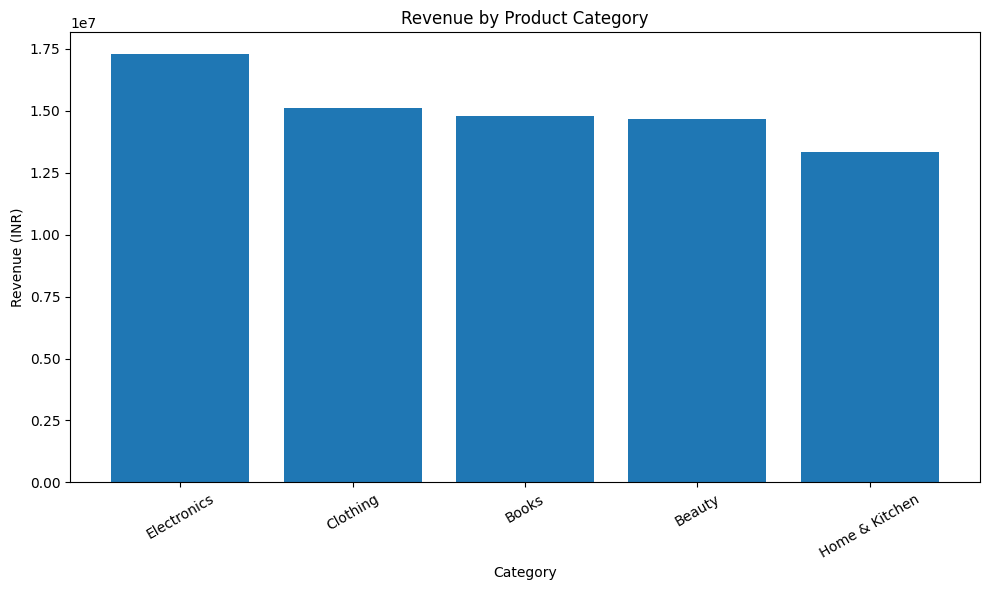

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis.index,
    category_analysis["Revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

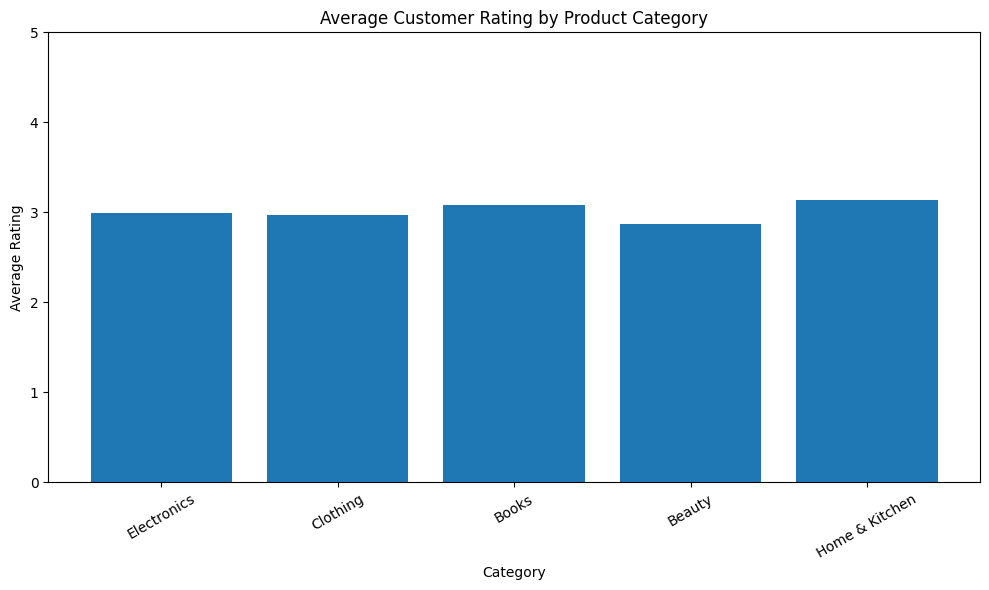

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis.index,
    category_analysis["Avg_Rating"]
)

plt.title("Average Customer Rating by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [26]:
top_products = (
    df.groupby("Product Name")
      .agg(
          Revenue=("Total Sales (INR)", "sum"),
          Units_Sold=("Quantity Sold", "sum"),
          Orders=("Order ID", "count"),
          Avg_Rating=("Customer Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
      .head(10)
)

top_products

,Revenue,Units_Sold,Orders,Avg_Rating
Product Name,,,,
Educational Book,4522055.35,188,64,3.064062
Laptop,4132783.72,156,48,2.881250
Table Lamp,3986691.68,141,46,2.891304
Headphones,3722765.27,135,44,2.829545
Jeans,3685259.60,132,42,2.992857
Smartwatch,3680177.80,137,47,3.110638
Face Cream,3646816.97,124,38,3.013158
Perfume,3266905.75,125,40,3.072500
Fiction Novel,3172999.91,138,41,3.060976


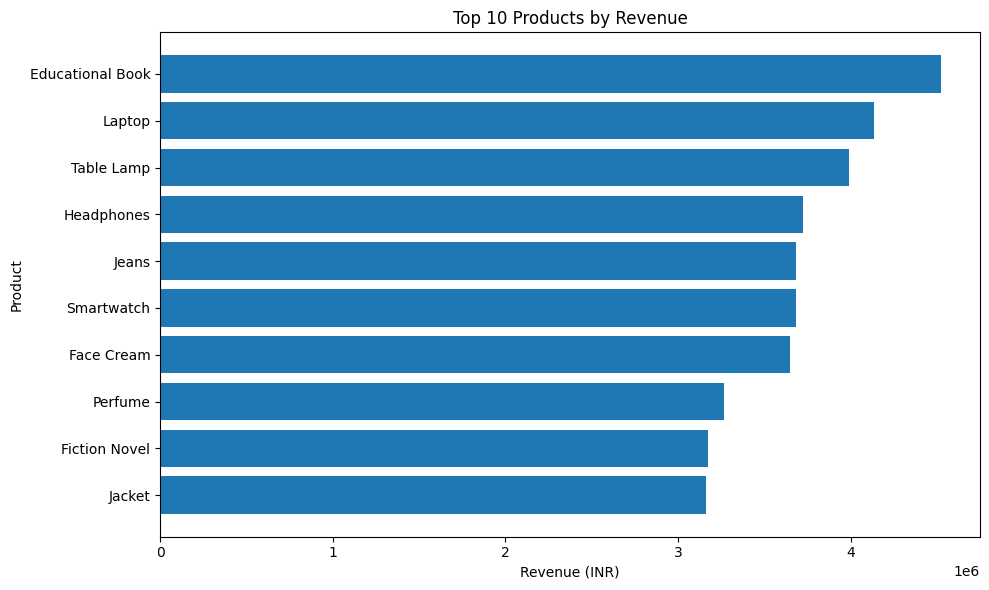

In [27]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index[::-1],
    top_products["Revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (INR)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [28]:
product_volume = (
    df.groupby("Product Name")
      .agg(
          Revenue=("Total Sales (INR)", "sum"),
          Units_Sold=("Quantity Sold", "sum")
      )
      .sort_values("Units_Sold", ascending=False)
)

product_volume.head(10)

,Revenue,Units_Sold
Product Name,,
Educational Book,4522055.35,188
Laptop,4132783.72,156
Table Lamp,3986691.68,141
Fiction Novel,3172999.91,138
Smartwatch,3680177.80,137
Headphones,3722765.27,135
Lipstick,2844209.08,134
Jeans,3685259.60,132
T-Shirt,2907013.32,131


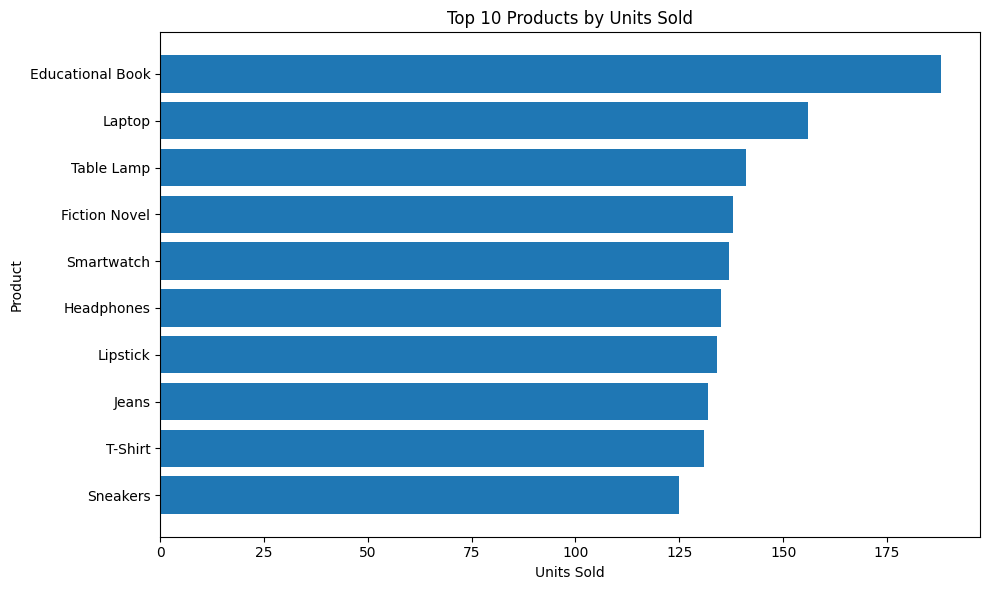

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    product_volume.head(10).index[::-1],
    product_volume.head(10)["Units_Sold"][::-1]
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [30]:
payment_analysis = (
    df.groupby("Payment Method")
      .agg(
          Revenue=("Total Sales (INR)", "sum"),
          Orders=("Order ID", "count"),
          Units_Sold=("Quantity Sold", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

payment_analysis

,Revenue,Orders,Units_Sold
Payment Method,,,
Wallet,13446764.16,172,543
Net Banking,13219947.52,166,522
UPI,12790919.48,176,537
COD,12457136.55,169,511
Debit Card,12142559.04,171,526
Credit Card,11155785.99,146,458


In [31]:
payment_analysis["Revenue %"] = (
    payment_analysis["Revenue"] /
    df["Total Sales (INR)"].sum() * 100
).round(2)

payment_analysis

,Revenue,Orders,Units_Sold,Revenue %
Payment Method,,,,
Wallet,13446764.16,172,543,17.88
Net Banking,13219947.52,166,522,17.58
UPI,12790919.48,176,537,17.01
COD,12457136.55,169,511,16.56
Debit Card,12142559.04,171,526,16.14
Credit Card,11155785.99,146,458,14.83


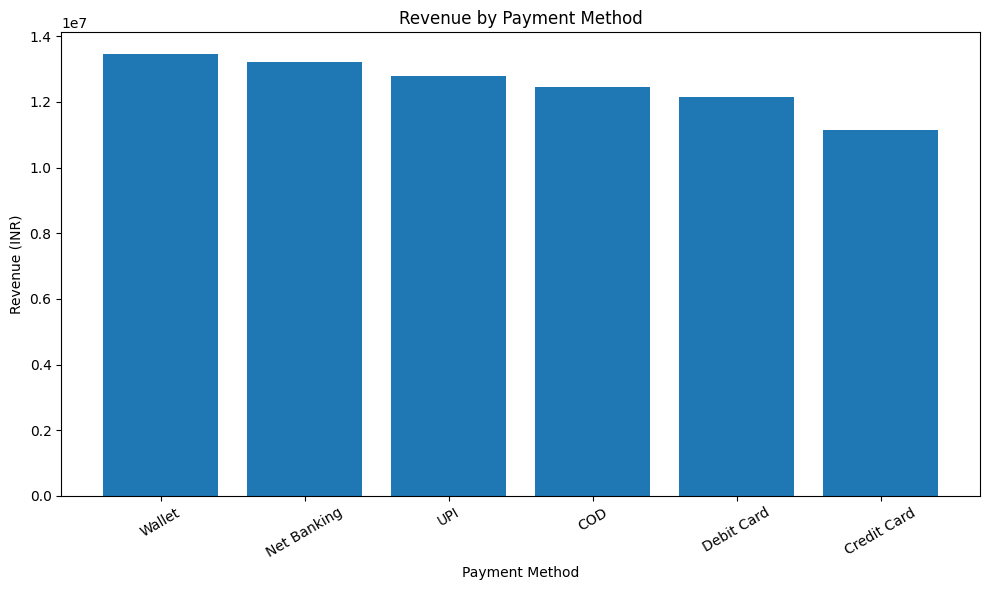

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    payment_analysis.index,
    payment_analysis["Revenue"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [33]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          Revenue=("Total Sales (INR)", "sum"),
          Orders=("Order ID", "count"),
          Units_Sold=("Quantity Sold", "sum")
      )
)

monthly_sales

,Revenue,Orders,Units_Sold
Order Date,,,
2024-02,3910477.01,47,156
2024-03,6508879.04,84,263
2024-04,7334962.92,79,267
2024-05,6706004.97,93,278
2024-06,4992364.75,83,236
2024-07,7637324.95,97,309
2024-08,5418893.98,86,266
2024-09,6264222.31,88,270
2024-10,5702923.37,79,216


In [34]:
monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales

,Revenue,Orders,Units_Sold
Order Date,,,
2024-02,3910477.01,47,156
2024-03,6508879.04,84,263
2024-04,7334962.92,79,267
2024-05,6706004.97,93,278
2024-06,4992364.75,83,236
2024-07,7637324.95,97,309
2024-08,5418893.98,86,266
2024-09,6264222.31,88,270
2024-10,5702923.37,79,216


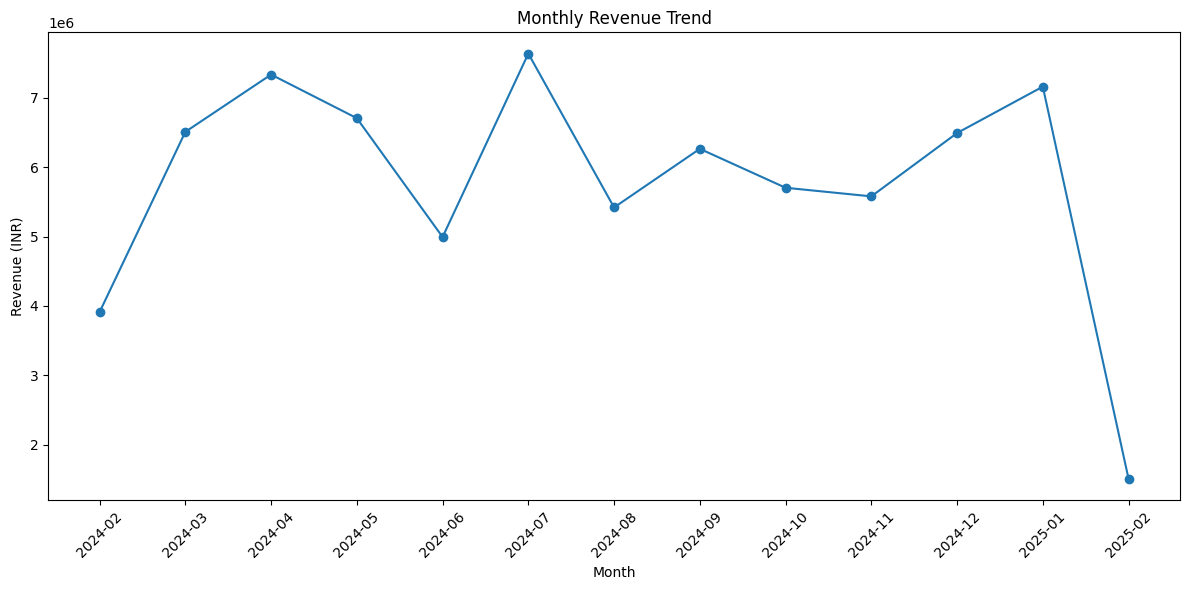

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [36]:
monthly_sales["AOV"] = (
    monthly_sales["Revenue"] / monthly_sales["Orders"]
).round(2)

monthly_sales.sort_values("Revenue", ascending=False)

,Revenue,Orders,Units_Sold,AOV
Order Date,,,,
2024-07,7637324.95,97,309,78735.31
2024-04,7334962.92,79,267,92847.63
2025-01,7160788.17,77,267,92997.25
2024-05,6706004.97,93,278,72107.58
2024-03,6508879.04,84,263,77486.66
2024-12,6491639.99,81,248,80143.70
2024-09,6264222.31,88,270,71184.34
2024-10,5702923.37,79,216,72188.90
2024-11,5578535.08,80,252,69731.69


In [37]:
monthly_sales.sort_values("AOV", ascending=False)

,Revenue,Orders,Units_Sold,AOV
Order Date,,,,
2025-01,7160788.17,77,267,92997.25
2024-04,7334962.92,79,267,92847.63
2024-02,3910477.01,47,156,83201.64
2024-12,6491639.99,81,248,80143.70
2024-07,7637324.95,97,309,78735.31
2024-03,6508879.04,84,263,77486.66
2024-10,5702923.37,79,216,72188.90
2024-05,6706004.97,93,278,72107.58
2024-09,6264222.31,88,270,71184.34


In [38]:
df["Customer Rating"].value_counts().sort_index()

,count
Customer Rating,
1.0,14
1.1,34
1.2,25
1.3,17
1.4,22
1.5,27
1.6,26
1.7,17
1.8,26


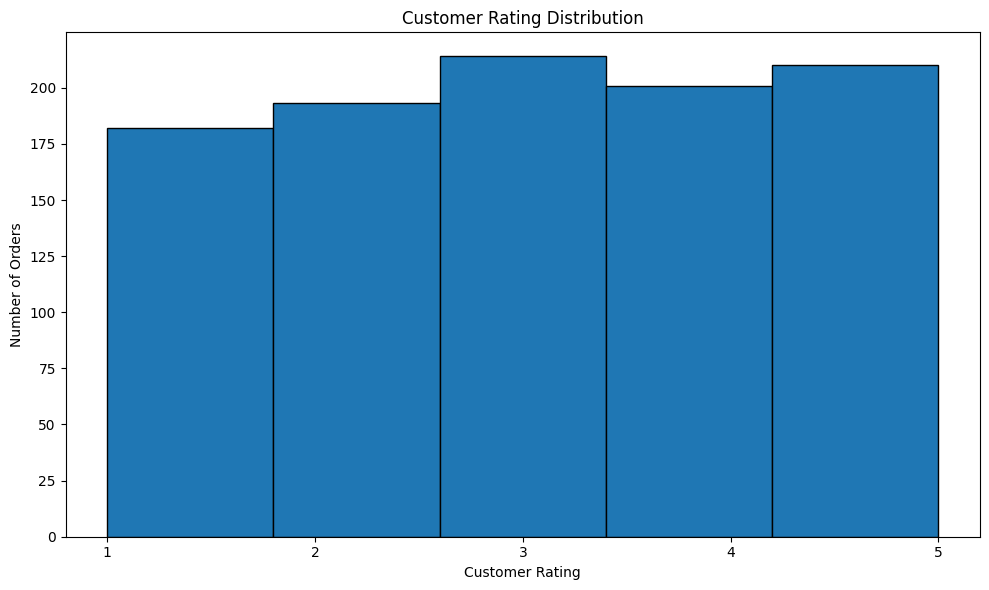

In [39]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Customer Rating"],
    bins=5,
    edgecolor="black"
)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

In [40]:
low_rated_products = (
    df.groupby("Product Name")
      .agg(
          Orders=("Order ID", "count"),
          Revenue=("Total Sales (INR)", "sum"),
          Avg_Rating=("Customer Rating", "mean")
      )
      .sort_values("Avg_Rating")
)

low_rated_products.head(10)

,Orders,Revenue,Avg_Rating
Product Name,,,
Hair Dryer,36,2505130.67,2.633333
Shampoo,34,2417521.58,2.805882
Lipstick,44,2844209.08,2.815909
Headphones,44,3722765.27,2.829545
Sneakers,39,2883134.96,2.874359
Laptop,48,4132783.72,2.881250
Table Lamp,46,3986691.68,2.891304
Mixer Grinder,36,2297176.60,2.902778
Self-Help Book,36,2638065.20,2.905556


In [41]:
rating_revenue = (
    df.groupby("Customer Rating")
      .agg(
          Revenue=("Total Sales (INR)", "sum"),
          Orders=("Order ID", "count")
      )
)

rating_revenue

,Revenue,Orders
Customer Rating,,
1.0,740312.83,14
1.1,2606466.96,34
1.2,2366120.22,25
1.3,1421794.44,17
1.4,1921657.51,22
1.5,1334178.24,27
1.6,1811803.19,26
1.7,1437245.23,17
1.8,2374539.81,26


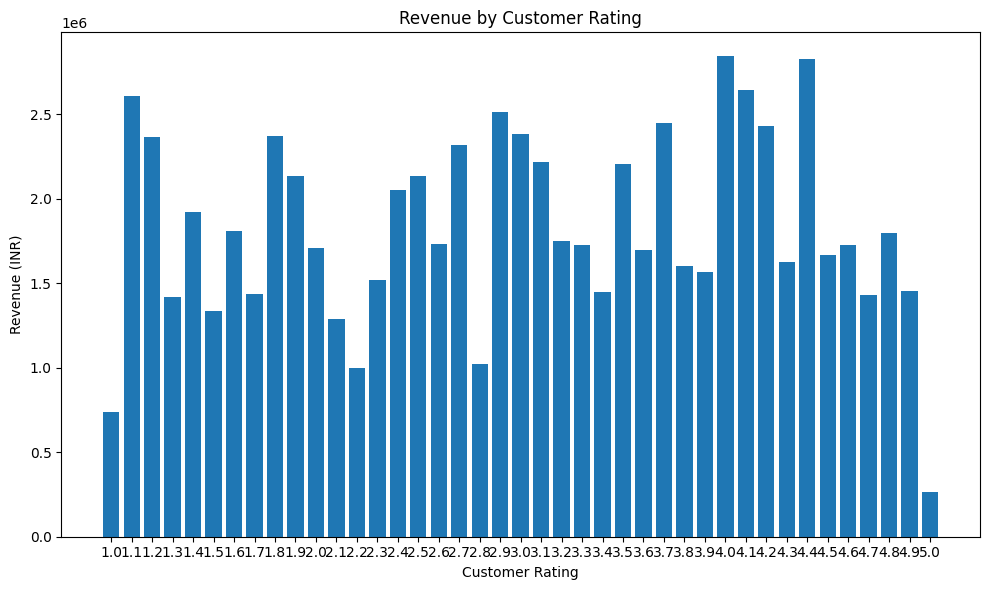

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(
    rating_revenue.index.astype(str),
    rating_revenue["Revenue"]
)

plt.title("Revenue by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Revenue (INR)")

plt.tight_layout()
plt.show()

In [43]:
rating_correlation = df["Customer Rating"].corr(
    df["Total Sales (INR)"]
)

print("Correlation between Customer Rating and Revenue:",
      round(rating_correlation, 3))

Correlation between Customer Rating and Revenue: -0.005


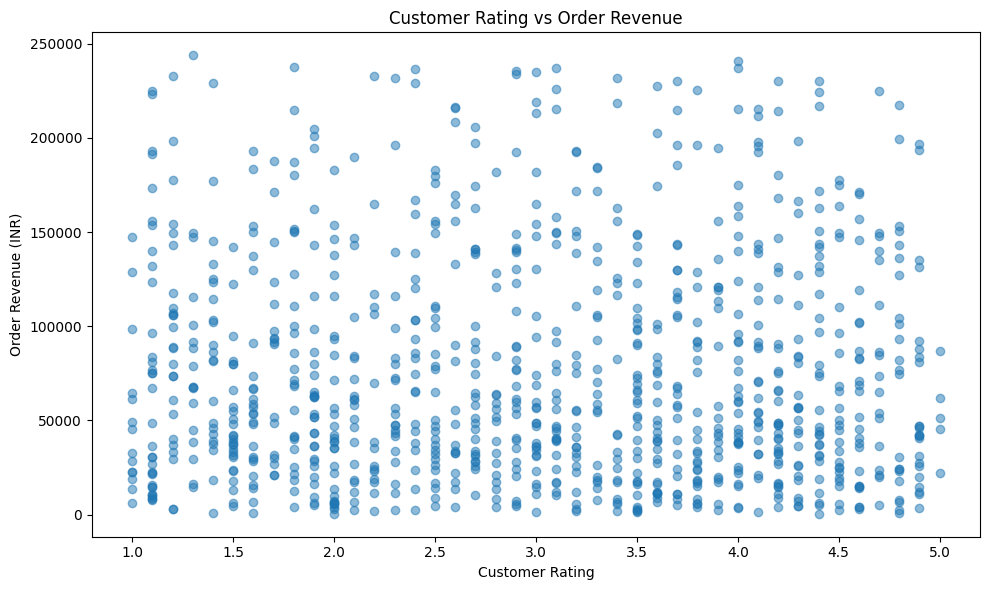

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Customer Rating"],
    df["Total Sales (INR)"],
    alpha=0.5
)

plt.title("Customer Rating vs Order Revenue")
plt.xlabel("Customer Rating")
plt.ylabel("Order Revenue (INR)")
plt.tight_layout()

plt.show()

In [45]:
category_summary = (
    df.groupby("Category")
      .agg(
          Revenue=("Total Sales (INR)", "sum"),
          Orders=("Order ID", "count"),
          Units_Sold=("Quantity Sold", "sum"),
          Avg_Order_Value=("Total Sales (INR)", "mean"),
          Avg_Rating=("Customer Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

category_summary["Revenue %"] = (
    category_summary["Revenue"] /
    df["Total Sales (INR)"].sum() * 100
).round(2)

category_summary["Avg_Order_Value"] = (
    category_summary["Avg_Order_Value"].round(2)
)

category_summary["Avg_Rating"] = (
    category_summary["Avg_Rating"].round(2)
)

category_summary

,Revenue,Orders,Units_Sold,Avg_Order_Value,Avg_Rating,Revenue %
Category,,,,,,
Electronics,17307173.07,217,673,79756.56,2.99,23.01
Clothing,15114386.86,189,609,79970.30,2.97,20.10
Books,14785759.65,209,653,70745.26,3.08,19.66
Beauty,14680584.05,192,583,76461.38,2.87,19.52
Home & Kitchen,13325209.11,193,579,69042.53,3.14,17.72


In [46]:
print("===== FLIPKART BUSINESS SUMMARY =====")
print(f"Total Revenue: ₹{df['Total Sales (INR)'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique():,}")
print(f"Total Units Sold: {df['Quantity Sold'].sum():,}")
print(f"Average Order Value: ₹{df['Total Sales (INR)'].mean():,.2f}")
print(f"Average Customer Rating: {df['Customer Rating'].mean():.2f}/5")
print(f"Top Revenue Category: {category_summary.index[0]}")
print(f"Top Revenue Product: {top_products.index[0]}")
print(f"Top Payment Method by Revenue: {payment_analysis.index[0]}")
print(f"Best Revenue Month: {monthly_sales['Revenue'].idxmax()}")

===== FLIPKART BUSINESS SUMMARY =====
Total Revenue: ₹75,213,112.74
Total Orders: 1,000
Total Units Sold: 3,097
Average Order Value: ₹75,213.11
Average Customer Rating: 3.01/5
Top Revenue Category: Electronics
Top Revenue Product: Educational Book
Top Payment Method by Revenue: Wallet
Best Revenue Month: 2024-07


In [47]:
from google.colab import files
files.download("flipkart_analysis (1).csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>